# PSO + Bayesian Optimization + LSTM Hybrid Framework
This notebook performs:
1. Synthetic cloud task dataset generation
2. Preprocessing and sequence creation
3. LSTM definition
4. PSO hyperparameter tuning
5. (Optional) Bayesian optimization using Optuna
6. Final training and evaluation


In [ ]:
!pip install optuna tensorflow scikit-learn matplotlib pandas numpy
import os, random, math, time, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 7.3 MB/s eta 0:00:00


In [ ]:
# 1. Synthetic Dataset Generation
n_tasks = 1000
task_length = np.random.lognormal(mean=3.5, sigma=0.7, size=n_tasks)
cpu_cores_needed = np.random.choice([1,2,4,8], size=n_tasks, p=[0.45,0.35,0.15,0.05])
memory_needed = np.clip(np.random.normal(loc=1024, scale=400, size=n_tasks), 128, 8192).astype(int)
network_bandwidth = np.clip(np.random.exponential(scale=50, size=n_tasks), 0.1, 1000)
priority = np.random.choice([1,2,3,4,5], size=n_tasks, p=[0.05,0.15,0.5,0.2,0.1])
arrival_time = np.cumsum(np.random.exponential(scale=1.0, size=n_tasks))
vm_ids = np.random.choice([f'vm_{i}' for i in range(12)], size=n_tasks, replace=True)

df = pd.DataFrame({
    'task_length': task_length,
    'cpu_cores_needed': cpu_cores_needed,
    'memory_needed': memory_needed,
    'network_bandwidth_needed': network_bandwidth,
    'priority': priority,
    'vm_id': vm_ids,
    'arrival_time': arrival_time
})
df.to_csv('optimized_tasks_vms.csv', index=False)
print('Saved synthetic dataset as optimized_tasks_vms.csv')


Saved synthetic dataset as optimized_tasks_vms.csv


In [ ]:
# 2. Preprocessing
df = df.sort_values('arrival_time').reset_index(drop=True)
le = LabelEncoder(); df['vm_id_enc'] = le.fit_transform(df['vm_id'])
features = ['task_length','cpu_cores_needed','memory_needed','network_bandwidth_needed','priority','vm_id_enc']
scaler = MinMaxScaler(); scaled = scaler.fit_transform(df[features])

WINDOW = 10
def create_sequences(data, window=WINDOW):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window, :])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, WINDOW)
split = int(0.8*len(X)); train_X, test_X, train_y, test_y = X[:split], X[split:], y[:split], y[split:]


In [ ]:
# 3. LSTM Builder
def build_lstm_model(units=64, dropout=0.2, lr=1e-3, input_shape=None):
    tf.keras.backend.clear_session()
    model = Sequential([
        LSTM(int(units), input_shape=input_shape),
        Dropout(float(dropout)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model


In [ ]:
# 4. PSO Tuning
def train_eval(params, epochs=4, verbose=0):
    m = build_lstm_model(params['units'], params['dropout'], params['lr'], (train_X.shape[1], train_X.shape[2]))
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    m.fit(train_X, train_y, validation_split=0.15, epochs=epochs, batch_size=32, verbose=verbose, callbacks=[es])
    return m.evaluate(test_X, test_y, verbose=0)[0]

import math
import numpy as np

# bounds (same as before)
bounds = {
    "units": (16, 128),
    "dropout": (0.0, 0.5),
    "lr": (1e-5, 1e-2)   # we optimize log(lr)
}

def rand_particle():
    return np.array([
        np.random.uniform(bounds["units"][0], bounds["units"][1]),
        np.random.uniform(bounds["dropout"][0], bounds["dropout"][1]),
        np.random.uniform(math.log(bounds["lr"][0]), math.log(bounds["lr"][1]))
    ])

def particle_to_params(p):
    # clip to valid raw ranges and return usable params
    u = int(np.clip(p[0], bounds["units"][0], bounds["units"][1]))
    d = float(np.clip(p[1], bounds["dropout"][0], bounds["dropout"][1]))
    lr = float(np.clip(math.exp(p[2]), bounds["lr"][0], bounds["lr"][1]))
    return {"units": u, "dropout": d, "lr": lr}

def run_pso(swarm=6, iters=5):
    # initialize swarm
    pos = np.array([rand_particle() for _ in range(swarm)])
    vel = np.zeros_like(pos)
    pbest = pos.copy()
    pbest_score = np.array([np.inf]*swarm)

    # Evaluate initial positions to populate pbest and gbest
    gbest = None
    gbest_score = np.inf
    for i in range(swarm):
        params = particle_to_params(pos[i])
        try:
            loss = train_eval(params, epochs=3, verbose=0)  # quick eval
        except Exception as e:
            # if training fails for some reason, give a large loss
            print(f"Initial eval failed for particle {i}: {e}")
            loss = np.inf
        pbest_score[i] = loss
        pbest[i] = pos[i].copy()
        if loss < gbest_score:
            gbest_score = loss
            gbest = pos[i].copy()

    w, c1, c2 = 0.5, 1.0, 1.0
    for t in range(iters):
        print(f"PSO iter {t+1}/{iters} — current gbest loss: {gbest_score:.6f}")
        for i in range(swarm):
            # velocity update (uses current pbest and global best)
            r1 = np.random.rand(3)
            r2 = np.random.rand(3)
            vel[i] = w*vel[i] + c1*r1*(pbest[i] - pos[i]) + c2*r2*(gbest - pos[i])
            pos[i] = pos[i] + vel[i]

            # IMPORTANT: clamp raw position values to valid ranges to avoid invalid hyperparams
            pos[i][0] = np.clip(pos[i][0], bounds["units"][0], bounds["units"][1])              # units
            pos[i][1] = np.clip(pos[i][1], bounds["dropout"][0], bounds["dropout"][1])           # dropout
            pos[i][2] = np.clip(pos[i][2], math.log(bounds["lr"][0]), math.log(bounds["lr"][1])) # log(lr)

            # evaluate the new position
            params = particle_to_params(pos[i])
            try:
                loss = train_eval(params, epochs=3, verbose=0)
            except Exception as e:
                print(f"Eval failed at iter {t+1} particle {i}: {e}")
                loss = np.inf

            # update personal best
            if loss < pbest_score[i]:
                pbest_score[i] = loss
                pbest[i] = pos[i].copy()

            # update global best
            if loss < gbest_score:
                gbest_score = loss
                gbest = pos[i].copy()

            print(f" particle {i}: units={params['units']}, dropout={params['dropout']:.3f}, lr={params['lr']:.4g}, loss={loss:.6f}")

    # final safe params from gbest (clipped)
    best_params = particle_to_params(gbest)
    return best_params, gbest_score



In [ ]:
# 5. Bayesian Optimization with Optuna

import optuna
def objective(trial):
    u = trial.suggest_int('units',16,128)
    d = trial.suggest_float('dropout',0,0.5)
    lr = trial.suggest_loguniform('lr',1e-5,1e-2)
    return train_eval({'units':u,'dropout':d,'lr':lr})
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)
print('Optuna best:', study.best_trial.params)



[I 2025-10-17 16:55:21,991] A new study created in memory with name: no-name-23f1a801-6679-40ed-8d2d-ec547011d525
/tmp/ipython-input-1754883830.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr',1e-5,1e-2)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2025-10-17 16:55:27,920] Trial 0 finished with value: 0.004889674950391054 and parameters: {'units': 19, 'dropout': 0.22794429317810866, 'lr': 0.0006671840466778259}. Best is trial 0 with value: 0.004889674950391054.
[I 2025-10-17 16:55:36,628] Trial 1 finished with value: 0.004852255340665579 and parameter

Optuna best: {'units': 19, 'dropout': 0.05081907164707783, 'lr': 0.000650501822813289}


⚠️ PSO not run — using default hyperparameters for training.
Using parameters: {'units': 64, 'dropout': 0.25, 'lr': 0.001}
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0102 - mae: 0.0787 - val_loss: 0.0044 - val_mae: 0.0469
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070 - mae: 0.0612 - val_loss: 0.0046 - val_mae: 0.0495
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - mae: 0.0570 - val_loss: 0.0043 - val_mae: 0.0447
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - mae: 0.0551 - val_loss: 0.0043 - val_mae: 0.0445
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060 - mae: 0.0546 - val_loss: 0.0043 - val_mae: 0.0454
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0061 - mae: 0.0520 - val_loss: 0.0043 - val_mae: 0.0450
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

✅ Final Model Evaluation — RMSE: 34.0719


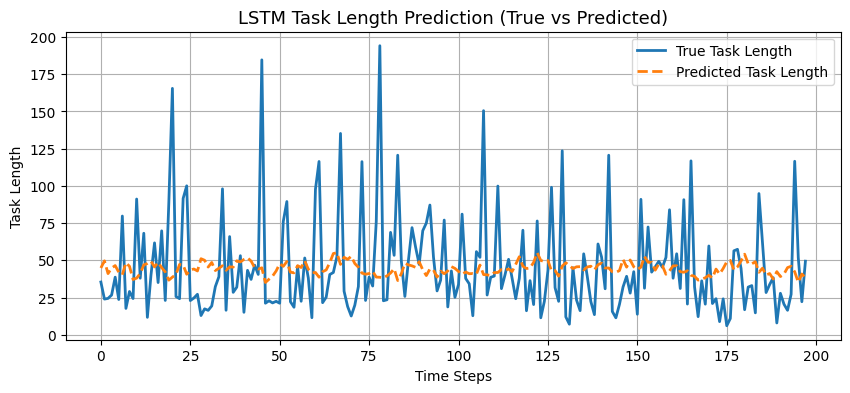

Model saved as best_LSTM_model.h5


In [ ]:
# 6. Final Training & Evaluation

# ✅ Safety check: use PSO results if available, else fallback
if 'best_pso_params' not in globals():
    print("⚠️ PSO not run — using default hyperparameters for training.")
    best_pso_params = {'units': 64, 'dropout': 0.25, 'lr': 0.001}

params = best_pso_params
print(f"Using parameters: {params}")

# Build and train the model
model = build_lstm_model(
    params['units'],
    params['dropout'],
    params['lr'],
    (train_X.shape[1], train_X.shape[2])
)

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_X, train_y,
    validation_split=0.15,
    epochs=15,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

# Predictions
pred = model.predict(test_X)

# ✅ Proper inverse scaling using the original MinMaxScaler
ph = np.zeros((len(pred), len(features)))
ph[:, 0] = pred[:, 0]
inv_pred = scaler.inverse_transform(ph)[:, 0]   # use the same 'scaler'

ph2 = np.zeros((len(test_y), len(features)))
ph2[:, 0] = test_y
inv_true = scaler.inverse_transform(ph2)[:, 0]

# RMSE evaluation
rmse = math.sqrt(mean_squared_error(inv_true, inv_pred))
print(f"\n✅ Final Model Evaluation — RMSE: {rmse:.4f}")

# Visualization
plt.figure(figsize=(10, 4))
plt.plot(inv_true[:200], label='True Task Length', linewidth=2)
plt.plot(inv_pred[:200], label='Predicted Task Length', linewidth=2, linestyle='--')
plt.title("LSTM Task Length Prediction (True vs Predicted)", fontsize=13)
plt.xlabel("Time Steps")
plt.ylabel("Task Length")
plt.legend()
plt.grid(True)
plt.show()

# Save model (optional)
model.save("best_LSTM_model.h5")
print("Model saved as best_LSTM_model.h5")
